In [1]:
import numpy as np
from scipy.optimize import brentq, minimize_scalar
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
import os
import sys
import astropy.io.fits as fits
from datetime import datetime
import pandas as pd
import matplotlib as mpl
from matplotlib.font_manager import FontProperties
import matplotlib.ticker as ticker
from src.utils.calculations import *
from src.utils.plotting_utils import *

plt.rcParams["axes.formatter.use_mathtext"]
c = datetime.now()
# Displays Time
current_time = c.strftime('%H%M')
print("current time :", current_time)
path = '/data/a.saricaoglu/repo/capture'

# # Import COMPAS specific scripts
compasRootDir = os.environ['COMPAS_ROOT_DIR']
sys.path.append(compasRootDir + '/postProcessing/PythonScripts')
print(sys.path)

pathToData = '/data/a.saricaoglu/repo/COMPAS/Files/bhvscomp.fits'


current time : 1605
['/grad/a.saricaoglu/.conda/envs/captus/lib/python312.zip', '/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12', '/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/lib-dynload', '', '/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages', '/data/a.saricaoglu/repo/captus', '/data/a.saricaoglu/repo/luxetenebrae/COMPAS/postProcessing/PythonScripts']


In [2]:
print(const.c)

  Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2018


In [3]:
limit_in_m = 1e6 * u.au.to(u.m)
print(f'Limit in meters: {limit_in_m}')

Limit in meters: 1.495978707e+17


In [68]:
phi = -np.pi
# print(R_star)
# print(R_star.to(u.au))
def galactic_dm_maxwell_dist(v, v_disp=220e3, vesc=550e3):
    f_vinf = (np.sqrt(2/np.pi)) * (v**2 / (v_disp**3)) * np.exp(- (v)**2/(2*v_disp**2)) * np.heaviside(vesc-v, 0)
    return f_vinf

def coalescence_time(b, M_pbh, M_star, v_inf):
    # omega_0 = np.sqrt(G * (M_pbh + M_star) / a**3)
    # T_0 = 2 * np.pi / omega_0
    e = eccentricity_original(b, M_pbh, M_star, v_inf)
    mu = (M_pbh * M_star) / (M_pbh + M_star)
    R0 = b * np.sqrt((e**2 - 1))
    return (5/256) * (const.c.value**5 * R0**4) / (G**3 * mu *(M_pbh + M_star)**2)


def orbital_energy(M_pbh, M_star, v_inf, b, e):
    mu = (M_pbh * M_star) / (M_pbh + M_star)
    R = b * np.sqrt((e**2 - 1))
    r = R / (1 + e * np.cos(phi))
    L = orbital_momentum(M_pbh, M_star, v_inf,e, r)
    KE = 0.5 * mu * v_inf**2
    LE = 0.5 * (L**2) / (mu * r**2)
    PE = - G * mu * (M_star + M_pbh) / r
    return KE + PE + LE

def orbital_momentum(M_pbh, M_star, v_inf, e, r):
    mu = (M_pbh * M_star) / (M_pbh + M_star)

    R = r * (1 + e * np.cos(phi))
    psi = np.sqrt(G*(M_star + M_pbh) * R) / r**2
    L = mu * r**2 * psi

    return L

def r_minimum(M_star, M_pbh, v_inf, e):
    return G * (M_star + M_pbh) * (e-1) / (v_inf**2)

def b_minimum(M_star, M_pbh, R_star, v_inf):
    return np.sqrt(R_star**2 + (2 * G *(M_star + M_pbh) * R_star) / v_inf**2)

def p_e(e):
    return ((e + 1)**-3.5) * ((np.arccos(-1/e) * (24 + 73*e**2 + ((37/4)*e**4))) + (602 + 673*e**2) * np.sqrt(e**2 - 1)/12)

def eccentricity(b, M_pbh, M_star, v_inf):
    return 1 + 1e-9 * (b/(1e5))**2 * (v_inf/(2.2e5))**4 * (M_star/const.M_sun.value)**-2

def eccentricity_original(b, M_pbh, M_star, v_inf):
    return np.sqrt(1 + (b**2 * v_inf**4) / (G**2 * (M_star + M_pbh)**2))


# def delta_E_GW(b, M_pbh, M_star, v_inf):
#     e = eccentricity_original(b, M_pbh, M_star, v_inf)
    
#     pre_factor = (8/15) * (M_pbh**2 * M_star**2) / (M_pbh + M_star)**3
#     print('pre factor:', pre_factor)
#     return pre_factor * (p_e(e) / ((e - 1)**3.5)) * v_inf**7
def delta_E_GW(e, b, M_pbh, M_star, v_inf):

    pre_factor = ((8/15)  * (M_pbh**2 * M_star**2)) / ((M_star+ M_pbh)**3 * const.c.value**5)
    # print('pre factor:', pre_factor)
    return pre_factor * (p_e(e) / (e - 1)**3.5) * v_inf**7

def equation(b, M_pbh, M_star, v_inf):
    # Returns positive when GW loss < KE (no capture)
    # Returns negative when GW loss > KE (capture possible)
    e = eccentricity(b, M_pbh, M_star, v_inf)
    return -delta_E_GW(e, b, M_pbh, M_star, v_inf) + orbital_energy(M_pbh, M_star, v_inf, b, e)

def compute_b_max(M_pbh, M_star, v_inf, b_min):
    """
    Find maximum b where |GW energy loss| ≥ kinetic energy
    
    At b_min: GW loss is very large (close encounter) → equation < 0
    As b increases: GW loss decreases → equation approaches 0 then becomes positive
    
    We want the b where equation = 0 (transition point)
    """
    e = eccentricity(b_min, M_pbh, M_star, v_inf)
    # Check if capture is possible at b_min
    eq_at_bmin = equation(b_min, M_pbh, M_star, v_inf)
    
    if eq_at_bmin > 0:
        # Even at closest approach, GW loss < KE → no capture possible
        return b_min
    
    # Find where equation crosses zero (GW loss = KE)
    b_guess_max = b_min  # Start with 10x b_min
    
    # Expand search until we bracket the root
    while b_guess_max < limit_in_m:
        eq_at_bmax = equation(b_guess_max, M_pbh, M_star, v_inf)
        # print(f'bmax guess: {b_guess_max}, equation: {eq_at_bmax}')
        if eq_at_bmax >= 0:
            # Found sign change! equation(b_min) < 0, equation(b_max) > 0
            try:
                b_max = brentq(equation, b_min, b_guess_max,
                              args=(M_pbh, M_star, v_inf),
                              xtol=1e-5, rtol=1e-5)
                # print(f'bmax found: {b_max}')
                return b_max
            except ValueError:
                return 0
        
        # Still negative - need larger b
        b_guess_max *= 1.5
        

    
    return 0

def compute_capture_crossec(b_min, b_max):
    if b_max <= b_min:
        return 0
    else:
        return np.pi * (b_max**2 - b_min**2)
    
def compute_semimajor_axis(b_ave, M_pbh, M_star, v_inf):

    # b_ave = b_min + b_max / 2
    e = eccentricity_original(b_ave, M_pbh, M_star, v_inf)
     # Calculate the semimajor axis using the formula
    energy = orbital_energy(M_pbh, M_star, v_inf, b_ave, e)
    mu = (M_pbh * M_star) / (M_pbh + M_star)
    a = G * (M_star + M_pbh) * mu / (2 * abs(energy))
    return a
# def compute_semimajor_axis(M_pbh, M_star, v_inf, bmin, bmax):
#     # Calculate the semimajor axis using the formula
#     a = (G * (M_star + M_pbh) / (v_inf**2)) * (bmax - bmin)
#     return a



In [5]:

# # print(R_star)
# # print(R_star.to(u.au))
# def galactic_dm_maxwell_dist(v, v_disp=220e3):
#     f_vinf = (np.sqrt(2/np.pi)) * (v**2 / (v_disp**3)) * np.exp(- (v)**2/(2*v_disp**2))
#     return f_vinf
# def orbital_energy(M_pbh, M_star, v_inf, b):
#     mu = (M_pbh * M_star) / (M_pbh + M_star)
#     KE = 0.5 * M_pbh * v_inf**2
#     PE = - G * mu * (M_star + M_pbh) / (2*b)
#     return KE 

# def b_minimum(M_star, M_pbh, R_star, v_inf):
#     return np.sqrt(R_star**2 + (2 * G *(M_star) * R_star) / v_inf**2)

# def p_e(e):
#     return ((e + 1)**-3.5) * ((np.arccos(-1/e) * (24 + 73*e**2 + ((37/4)*e**4))) + (602 + 673*e**2) * np.sqrt(e**2 - 1)/12)

# def eccentricity(b, M_pbh, M_star, v_inf):
#     return 1 + 1e-9 * (b/(1e5))**2 * (v_inf/(2.2e5))**4 * (M_star/const.M_sun.value)**-2

# def eccentricity_original(b, M_pbh, M_star, v_inf):
#     return np.sqrt(1 + (b**2 * v_inf**4) / (G**2 * (M_star)**2))

# # def delta_E_GW(b, M_pbh, M_star, v_inf):
# #     e = eccentricity_original(b, M_pbh, M_star, v_inf)
    
# #     pre_factor = (8/15) * (M_pbh**2 * M_star**2) / (M_pbh + M_star)**3
# #     print('pre factor:', pre_factor)
# #     return pre_factor * (p_e(e) / ((e - 1)**3.5)) * v_inf**7
# def delta_E_GW(b, M_pbh, M_star, v_inf):
#     e = eccentricity_original(b, M_pbh, M_star, v_inf)

#     pre_factor = ((8/15)  * (M_pbh**2 * M_star**2)) / ((M_star+ M_pbh)**3 * const.c.value**5)
#     print('pre factor:', pre_factor)
#     return pre_factor * (p_e(e) / (e - 1)**3.5) * v_inf**7

# def equation(b, M_pbh, M_star, v_inf):
#     # Returns positive when GW loss < KE (no capture)
#     # Returns negative when GW loss > KE (capture possible)
#     return -delta_E_GW(b, M_pbh, M_star, v_inf) + orbital_energy(M_pbh, M_star, v_inf, b)

# def compute_b_max(M_pbh, M_star, v_inf, b_min):
#     """
#     Find maximum b where |GW energy loss| ≥ kinetic energy
    
#     At b_min: GW loss is very large (close encounter) → equation < 0
#     As b increases: GW loss decreases → equation approaches 0 then becomes positive
    
#     We want the b where equation = 0 (transition point)
#     """
    
#     # Check if capture is possible at b_min
#     eq_at_bmin = equation(b_min, M_pbh, M_star, v_inf)
    
#     if eq_at_bmin > 0:
#         # Even at closest approach, GW loss < KE → no capture possible
#         return b_min
    
#     # Find where equation crosses zero (GW loss = KE)
#     b_guess_max = b_min 
    
#     # Expand search until we bracket the root
#     for attempt in range(100):
#         eq_at_bmax = equation(b_guess_max, M_pbh, M_star, v_inf)
#         print(f'bmax guess: {b_guess_max}, equation: {eq_at_bmax}')
#         if eq_at_bmax >= 0:
#             # Found sign change! equation(b_min) < 0, equation(b_max) > 0
#             try:
#                 b_max = brentq(equation, b_min, b_guess_max,
#                               args=(M_pbh, M_star, v_inf),
#                               xtol=1e-5, rtol=1e-5)
#                 print(f'bmax found: {b_max}')
#                 return b_max
#             except ValueError:
#                 return 0
        
#         # Still negative - need larger b
#         b_guess_max *= 1.1
        

    
#     return 0

# def compute_capture_crossec(b_min, b_max):
#     if b_max <= b_min:
#         return 0
#     else:
#         return np.pi * (b_max**2 - b_min**2)
    
# def compute_semimajor_axis(M_pbh, M_star, v_inf):

#     return np.sqrt(G**2 * (M_star + M_pbh)**2 / (v_inf**4))
# # def compute_semimajor_axis(M_pbh, M_star, v_inf, bmin, bmax):
# #     # Calculate the semimajor axis using the formula
# #     a = (G * (M_star + M_pbh) / (v_inf**2)) * (bmax - bmin)
# #     return a



In [13]:

mod = 'Gravitational_Wave_Capture_'
if not os.path.exists(path+ "/plots/" + mod + "/"): 
    os.makedirs(path + "/plots/"  + mod + "/")
directoryp = path + "/plots/"  + mod + "/"

mpl.rc('font',family='DeJavu Serif')
font = FontProperties(family='DeJavu Serif')
plt.rcParams['savefig.dpi'] = 600  # Set the resolution for saved figures
# Set the number of lines to plot and the colormap
n_lines = 10
cmap = mpl.colormaps['plasma']
# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, n_lines))
G = const.G.value
# G = G * const.M_sun.value * 1/(const.c.value*const.R_sun.value)**3 # in 1/c^2 
# # Regulus
# star = 'Regulus'
# M_star =  4.15 * const.M_sun.value # in M_sun
# R_star = 3.22 * const.R_sun.value # in R_sun / c

# S Monocerotis
# star = 'S_Monocerotis'
# M_star =  29.1 * const.M_sun.value # in M_sun
# R_star = 0.9 * const.R_sun.value # in R_sun / c

# paper values
# star = 'paper'
# M_star =  2 * const.M_sun.value
# R_star = 10e3

# Beta Persei Aa1
# star = 'Beta_Persei_Aa1'
# M_star = 3.17 * const.M_sun.value # in M_sun
# R_star = 2.73 * const.R_sun.value # in R_sun / c t0 0.68

# V518 Persei
# star = 'V518_Persei'
# M_star =  0.47 * const.M_sun.value # in M_sun 0.26-0.68
# M_bh = 6.5 * const.M_sun.value # in M_sun 3.6 to 9.5
# R_star = const.R_sun.value * 0.45 

# star = 'GW200115'
# M_star =  1.25 * const.M_sun.value # in M_sun 0.26-0.68
# M_bh = 7 * const.M_sun.value # in M_sun 3.6 to 9.5
# R_star = 0.000015 * const.R_sun.value # in R_sun / c
# Cygnus X-1
# star = 'Cygnus_X-1'
# M_star =  30* const.M_sun.value # in M_sun
# M_bh = 15 * const.M_sun.value # in M_sun
# R_star = 2 * const.R_sun.value # in R_sun /

# Sun
# star = 'Sun'
# M_star = const.M_sun.value # in M_sun
# R_star = const.R_sun.value /1000 # in R_sun

# star = 'PSR J0348+0432'
# M_star = 2.01 * const.M_sun.value # in M_sun
# R_star = 13e3 # in meters

# star = 'ZTF J1901+1458'
# M_star = 1.35 * const.M_sun.value # in M_sun
# R_star = 2.1e6 # in meters

# star = 'PSR J1921+2153'
# M_star = 1.3 * const.M_sun.value # in M_sun
# R_star = 1.4e-5 * const.R_sun.value # in
star = 'Typical_Neutron_Star'
M_star = 1.4 * const.M_sun.value # in M_sun
R_star = 11e3 # in meters

gridsize = 100
m_pbh_values = np.logspace(-10, 2, gridsize) * const.M_sun.value # in M_sun
v_inf_values = np.logspace(3, 6, gridsize) # in m/s

M_grid, V_grid = np.meshgrid(m_pbh_values, v_inf_values)
cross_section_grid = np.zeros_like(M_grid)

Hubble_time = 13.8e9

equation(b_min): 2.0747290638922644e+26
equation at bmax guess: 9.218984714096599e+26
equation(b_min): 2.683672433341443e+26
equation at bmax guess: 1.2186955240735663e+27
equation(b_min): 3.444557582113173e+26
equation at bmax guess: 1.6110437607403034e+27
equation(b_min): 4.373333212742266e+26
equation at bmax guess: 2.1297050393301748e+27
equation(b_min): 5.4664383478429515e+26
equation at bmax guess: 2.815344725635143e+27
equation(b_min): 6.67609910440049e+26
equation at bmax guess: 3.7217200400197356e+27
equation(b_min): 7.863901322994764e+26
equation at bmax guess: 4.9198948641227315e+27
equation(b_min): 8.715350822446993e+26
equation at bmax guess: 6.503811467272662e+27
equation(b_min): 8.584871951503037e+26
equation at bmax guess: 8.597656000911052e+27
equation(b_min): 6.217412256904382e+26
equation at bmax guess: 1.1365595248760747e+28
equation(b_min): -7.480100603071594e+25
equation at bmax guess: 1.5024648037545854e+28
equation(b_min): -1.6659022783454503e+27
equation at bma

/tmp/ipykernel_1927216/2806460886.py:27: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),
/tmp/ipykernel_1927216/2806460886.py:27: UserWarning: The following kwargs were not used by contour: 'aspect'
  plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),


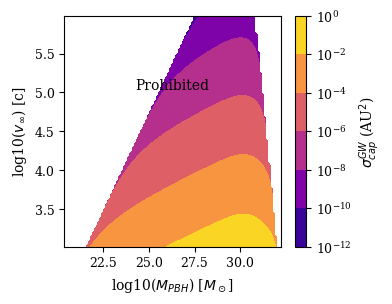

In [31]:

# Figure 1
b_max_values = np.zeros_like(M_grid)
b_min_values = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        b_min = b_minimum(M_star, m_pbh_values[j], R_star, v_inf_values[i])
        b_min_values[i, j] = b_min
        # print(equation(b_min_values, M_grid[i, j], M_star, V_grid[i, j]))
        b_max = compute_b_max(m_pbh_values[j], M_star, v_inf_values[i], b_min)
        b_max_values[i, j] = b_max
        b_min_au = (b_min * u.m).to(u.au).value
        # print(f'bmin: {b_min_au}')
        # print(f'p(e) at bmin: {p_e(eccentricity_original(b_min, m_pbh_values[j], M_star, v_inf_values[i]))}')
        # print(f'eccentricity at bmin: {eccentricity_original(b_min, m_pbh_values[j], M_star, v_inf_values[i])}')
        print(f'equation(b_min): {equation(b_min, m_pbh_values[j], M_star, v_inf_values[i])}')
        print(f'equation at bmax guess: {equation(b_min*1000000, m_pbh_values[j], M_star, v_inf_values[i])}')
        b_max_au = (b_max * u.m).to(u.au).value
        cs = compute_capture_crossec(b_min_au, b_max_au)
        # cs_au = (cs * u.m**2).to(u.au**2).value
        cross_section_grid[i, j] = cs
cross_section_grid = cross_section_grid
# print('crossec max', np.max(cross_section_grid))
# print('b_max max', np.max(b_max_values))
# print('b_min max', np.max(b_min_values))

plt.figure(figsize=(3.5,3))
plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),
                                                       np.log10(m_pbh_values[-1]),
                                                       np.log10(v_inf_values[0]),
                                                       np.log10(v_inf_values[-1])],
           aspect='auto', cmap='plasma', norm=plt.cm.colors.LogNorm())
# plt.hlines(np.log10(2/(3*10**4)), np.log10(m_pbh_values[0]), np.log10(m_pbh_values[-1]), color='blue', linestyle='--')
# plt.vlines(np.log10(m_pbh_values), np.log10(v_inf_values[0]), np.log10(v_inf_values[-1]), color='red', linestyle='--')
plt.xlabel(r'log10($M_{PBH}$) [$M_\odot$]')
plt.ylabel(r'log10($v_{\infty}$) [c]')
plt.text(0.5, 0.7, r'Prohibited', fontsize=10, ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, 0.6, r'(Capture without collision is not possible)', fontsize=8, ha='center', va='center', transform=plt.gca().transAxes)

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ (AU$^2$)')
# plt.title('Capture cross-section as function of PBH mass and velocity')
plt.savefig(directoryp + f'{star}_capture_cross_section_grid.png',bbox_inches='tight')
# plt.show()


NameError: name 'M_bh' is not defined

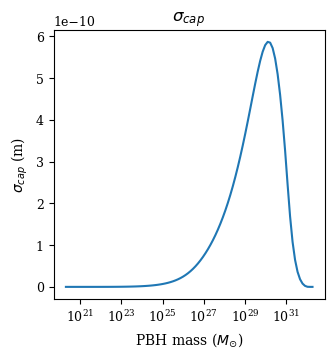

In [8]:

# Figure 3
plt.figure(figsize=(3.5,3.5))
rate = []
for m in m_pbh_values:
    v_int = 0
    for v in  v_inf_values:
        if v < (5.5e5 ):
            # print(m, M_star, R_star, v)
            b_min= b_minimum(M_star, m, R_star, v)
            f = galactic_dm_maxwell_dist(v)
            b_max = compute_b_max(m, M_star, v, b_min) 
            cs = compute_capture_crossec(b_min, b_max)
            cs_au = (cs * u.m**2).to(u.au**2).value
            v = (v * u.m / u.s).to(u.au / u.yr).value
            caprate_dv = f * cs_au * v
            v_int += caprate_dv
    rate.append(v_int)
rate = rate 
plt.plot(m_pbh_values, rate)
plt.xscale('log')
plt.xlabel(r"PBH mass ($M_{\odot}$)")
plt.ylabel(r"$\sigma_{cap}$ (m)")
plt.title(r"$\sigma_{cap}$ ")
plt.vlines(np.log10(M_bh), np.log10(v_inf_values[0]), np.log10(v_inf_values[-1]), color='red', linestyle='--')

plt.grid(True, which="both")
plt.savefig(directoryp + f'{star}_capture_rate.png')


/tmp/ipykernel_1617293/553690478.py:21: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),
/tmp/ipykernel_1617293/553690478.py:21: UserWarning: The following kwargs were not used by contour: 'aspect'
  plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),


NameError: name 'M_bh' is not defined

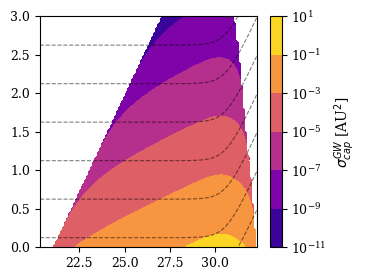

In [ ]:

# import pandas as pd
# M, V = np.meshgrid(m_pbh_values / const.M_sun, v_inf_values)
# data = pd.DataFrame({
#     "M_pbh (M_sun)": M.flatten(),
#     "v_inf (km/s)": V.flatten(),
#     "Cross section (au^2)":cross_section_grid.flatten()
# })

# plt.figure(figsize=(3.5,3.5))
# sns.kdeplot(x=data["M_pbh (M_sun)"], y=data["v_inf (km/s)"], weights=data["Cross section (au^2)"], fill=True, cmap='plasma')

# plt.yscale('log')
# plt.xlabel("PBH mass [$M_\\odot$]")
# plt.ylabel("Velocity [km/s]")
# plt.title("Capture cross section contour plot")
# plt.show()
plt.figure(figsize=(3.5, 3))
v_inf_values_kms = [v.to(u.km/u.s).value for v in (v_inf_values * u.m/u.s)]
v_inf_values_auyr = [v.to(u.au/u.yr).value for v in (v_inf_values * u.m/u.s)]

plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),
                                                       np.log10(m_pbh_values[-1]),
                                                       np.log10(v_inf_values_kms[0]),
                                                       np.log10(v_inf_values_kms[-1])],
           aspect='auto', cmap='plasma', norm=plt.cm.colors.LogNorm())
# plt.hlines(np.log10(2/(3*10**4)), np.log10(m_pbh_values[0]), np.log10(m_pbh_values[-1]), color='blue', linestyle='--')
cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')
contour = plt.contour(np.log10(m_pbh_values), np.log10(v_inf_values_kms),(semaj_grid),
                      colors='black', linewidths=0.8,  norm=plt.cm.colors.LogNorm(),
                      linestyles='--', alpha=0.5)
a = compute_semimajor_axis(M_bh, M_star, v_inf_values)
a = (a * u.m).to(u.au).value
# semaj_grid = np.zeros_like(M_grid)
# for i in range(gridsize):
#     for j in range(gridsize):
#         a = compute_semimajor_axis(M_bh, M_star, V_grid[i, j])
#         semaj_grid[i, j] = a
# semaj_grid = semaj_grid * (const.R_sun.value**2 * const.c.value**2) * 6.68459e-12


# contour2 = plt.contour(np.log10(m_pbh_values), np.log10(v_inf_values),(R_star_au),
#                       colors='blue', linewidths=0.8,  norm=plt.cm.colors.LogNorm(),
#                       linestyles='--', alpha=0.5)
plt.vlines(np.log10(M_bh), np.log10(v_inf_values_kms[0]), np.log10(v_inf_values_kms[-1]), color='red', linestyle='--', alpha=0.5)
# Add labels to the contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: f"{x:.0f} AU")
# plt.contour(np.log10(m_pbh_values), np.log10(v_inf_values),(semaj_grid),
#                         colors='blue', linewidths=0.8,  norm=plt.cm.colors.LogNorm(),
#                         linestyles='--', alpha=0.5)
# Add labels to the contour lines
# plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: f"{x:.1E} AU")
# plt.clabel(contour2, inline=True, fontsize=8, fmt=lambda x: f"R_star {x:.1E} AU")
plt.xlabel(r'log10($M_{PBH}$) [$M_\odot$]')
plt.ylabel(r'$v_{\infty}$ [km/s]')
plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, 0.6, r'(Capture without collision is not possible)', fontsize=10, ha='center', va='center', transform=plt.gca().transAxes)
plt.yticks(np.log10(v_inf_values_kms)[::10], [f'{x:.1g}' for x in (v_inf_values_kms)[::10]])# plt.title('Capture cross-section as function of PBH mass and velocity')
plt.savefig(directoryp + f'{star}_capture_cross_section_plus_semaj_grid.png',bbox_inches='tight')
# plt.show()



In [ ]:
semaj_grid = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        a = semimajor_axis(304*60, M_star, M_grid[i, j])
        semaj_grid[i, j] = (a*u.m).to(u.au).value
semaj_grid = semaj_grid 

semaj: 620.9896929670969
semaj: 620.9896929778067
semaj: 620.9896929919648
semaj: 620.9896930106812
semaj: 620.989693035423
semaj: 620.98969306813
semaj: 620.9896931113672
semaj: 620.9896931685238
semaj: 620.9896932440813
semaj: 620.9896933439643
semaj: 620.9894516008264
semaj: 620.9897226600955
semaj: 620.9895744074001
semaj: 620.989743794355
semaj: 620.989750053446
semaj: 620.9894702295487
semaj: 620.9897812700332
semaj: 620.9896639419288
semaj: 620.9898155582451
semaj: 620.989740424318
semaj: 620.9897446163114
semaj: 620.9897766805308
semaj: 620.9896869302871
semaj: 620.989525940415
semaj: 620.9895743155411
semaj: 620.9897370257117
semaj: 620.98954490512
semaj: 620.989549779297
semaj: 620.9896476551111
semaj: 620.9896038915666
semaj: 620.9897217539026
semaj: 620.9898471831182
semaj: 620.9899036208242
semaj: 620.9900642115402
semaj: 620.9901441608698
semaj: 620.9902544060453
semaj: 620.9905370853782
semaj: 620.9909635014003
semaj: 620.9913027587461
semaj: 620.9918854915974
semaj: 620

/tmp/ipykernel_1927216/4119997873.py:40: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(m_pbh_values_in_Mstar, v_inf_values_kms, cross_section_grid,


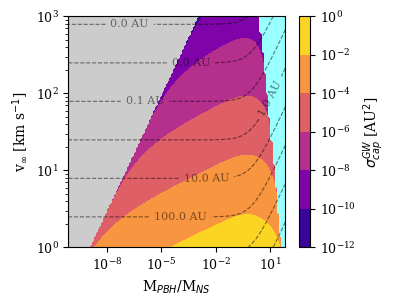

In [65]:

# import pandas as pd
# M, V = np.meshgrid(m_pbh_values / const.M_sun, v_inf_values)
# data = pd.DataFrame({
#     "M_pbh (M_sun)": M.flatten(),
#     "v_inf (km/s)": V.flatten(),
#     "Cross section (au^2)":cross_section_grid.flatten()
# })

# plt.figure(figsize=(3.5,3.5))
# sns.kdeplot(x=data["M_pbh (M_sun)"], y=data["v_inf (km/s)"], weights=data["Cross section (au^2)"], fill=True, cmap='plasma')

# plt.yscale('log')
# plt.xlabel("PBH mass [$M_\\odot$]")
# plt.ylabel("Velocity [km/s]")
# plt.title("Capture cross section contour plot")
# plt.show()
semaj_grid = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        Rb_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a = compute_semimajor_axis(Rb_ave, M_grid[i, j], M_star, V_grid[i, j])
        semaj_grid[i, j] = (a*u.m).to(u.au).value
        print(f'semaj: {semaj_grid[i, j]}')
semaj_grid = semaj_grid 
plt.figure(figsize=(3.5, 3))
v_inf_values_kms = [v.to(u.km/u.s).value for v in (v_inf_values * u.m/u.s)]
v_inf_values_auyr = [v.to(u.au/u.yr).value for v in (v_inf_values * u.m/u.s)]
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
m_pbh_values_in_Mstar = m_pbh_values / M_star

# Fill background in red between min PBH mass and 1 solar mass
plt.fill_betweenx(v_inf_values_kms, 
                  np.min(m_pbh_values_in_Mstar), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)
plt.fill_betweenx(v_inf_values_kms, 
                  1.0, 
                  np.max(m_pbh_values_in_Mstar),  # 1 solar mass
                  color='cyan', alpha=0.4, zorder=0)
plt.contourf(m_pbh_values_in_Mstar, v_inf_values_kms, cross_section_grid,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')

# ✅ Contour also uses linear values
contour = plt.contour(m_pbh_values_in_Mstar, v_inf_values_kms, semaj_grid,
                      colors='black', linewidths=0.8, norm=plt.cm.colors.LogNorm(),
                      linestyles='--', alpha=0.5)

# ✅ Vertical line uses LINEAR M_bh value
# plt.vlines(, v_inf_values_kms[0], v_inf_values_kms[-1], 
#            color='red', linestyle='--', alpha=0.5)

# Add labels to contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: fr"{x:.1f} AU")

plt.xlabel(r'M$_{PBH}$/M$_{NS}$')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)

# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_capture_cross_section_plus_semaj_grid.png', 
            bbox_inches='tight')


Capture rate for mPBH = 1.988409870698051e+20: 0.0
Capture rate for mPBH = 2.6285608280917688e+20: 0.0
Capture rate for mPBH = 3.474802719900449e+20: 0.0
Capture rate for mPBH = 4.5934846982380795e+20: 0.0
Capture rate for mPBH = 6.072316437449976e+20: 0.0
Capture rate for mPBH = 8.027244965171765e+20: 0.0
Capture rate for mPBH = 1.061154542827731e+21: 0.0
Capture rate for mPBH = 1.4027838550456344e+21: 0.0
Capture rate for mPBH = 1.8543977003886293e+21: 0.0
Capture rate for mPBH = 2.451404625764507e+21: 0.0
Capture rate for mPBH = 3.2406126463380813e+21: 0.0
Capture rate for mPBH = 4.283899203433699e+21: 1.6650643217551217e-10
Capture rate for mPBH = 5.66306263289985e+21: 1.6772295935805624e-09
Capture rate for mPBH = 7.486235520770679e+21: 3.3133649735517703e-09
Capture rate for mPBH = 9.896362782014772e+21: 5.445580766610739e-09
Capture rate for mPBH = 1.308240918169307e+22: 1.2624023132926163e-08
Capture rate for mPBH = 1.7294175018349853e+22: 2.0511676335070697e-08
Capture rate fo

/tmp/ipykernel_1927216/2313735181.py:48: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(m_pbh_values_in_Mstar, v_inf_values_kms, n_eqs_grid,


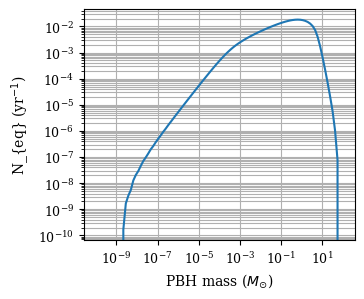

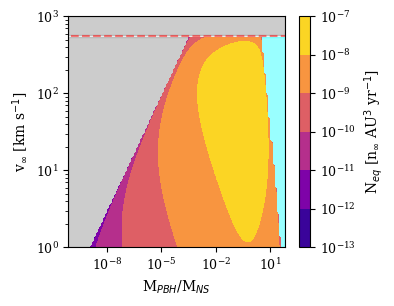

In [67]:

n_eqs_perpbh = []
n_eqs_grid = np.zeros_like(M_grid)
for j in range(gridsize):
    x_vals = []
    y_vals = []
    for i in range(gridsize):
        # print(m, M_star, R_star, v)
        v = v_inf_values[i]
        f = galactic_dm_maxwell_dist(v=v)
        caprate =  f * cross_section_grid[i, j] * v 
        y_vals.append(caprate)
        x_vals.append(v)
        n_eqs_grid[i, j] = caprate
    n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
    print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
    n_eqs_perpbh.append(n_eq)
plt.figure(figsize=(3.5,3))
plt.plot(m_pbh_values_in_Msun, n_eqs_perpbh)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"PBH mass ($M_{\odot}$)")
plt.ylabel(r"N_{eq} (yr$^{-1}$)")
plt.grid(True, which="both")
plt.savefig(directoryp + f'{star}_neq_per_mPBH.png')
    
plt.figure(figsize=(3.5,3))

# Filter velocities below 550 km/s
v_below_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) < 550]
v_above_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) >= 550]

# Fill for velocities < 550 km/s between min mass and 1 solar mass
plt.fill_betweenx(v_below_550, 
                  np.min(m_pbh_values_in_Mstar), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)

# Fill for velocities < 550 km/s between 1 solar mass and max mass
plt.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Mstar),
                  color='cyan', alpha=0.4, zorder=0)

# Fill prohibited region (all masses, v >= 550 km/s)
plt.fill_between(m_pbh_values_in_Mstar, v_above_550[0], np.max(v_inf_values_kms), 
                 alpha=0.4, color='gray', label='Prohibited Region')

plt.contourf(m_pbh_values_in_Mstar, v_inf_values_kms, n_eqs_grid,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')

plt.hlines(550, np.min(m_pbh_values_in_Msun), np.max(m_pbh_values_in_Msun), 
           color='red', linestyle='--', alpha=0.5, label=r'$v_{\infty} = 550$ km/s')
# ✅ Vertical line uses LINEAR M_bh value
# plt.vlines(, v_inf_values_kms[0], v_inf_values_kms[-1], 
#            color='red', linestyle='--', alpha=0.5)

# Add labels to contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: fr"{x:.1f} AU")

plt.xlabel(r'M$_{PBH}$/M$_{NS}$')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
cbar.set_label(r'N$_{eq}$ [n$_\infty$ AU$^{3}$ yr$^{-1}$]')
# plt.title('Capture cross-section as function of PBH mass and velocity')
plt.savefig(directoryp + f'{star}_neq_grid.png',bbox_inches='tight')
    


Coalescence time for mPBH = 1.988409870698051e+20, v = 1000.0: 24184229.98810523 24184229.98810523
Coalescence time for mPBH = 1.988409870698051e+20, v = 1072.2672220103232: 24184228.852815494 24184228.852815494
Coalescence time for mPBH = 1.988409870698051e+20, v = 1149.7569953977356: 24184255.74628278 24184255.74628278
Coalescence time for mPBH = 1.988409870698051e+20, v = 1232.8467394420659: 24184238.120352693 24184238.120352693
Coalescence time for mPBH = 1.988409870698051e+20, v = 1321.9411484660286: 24184230.783209413 24184230.783209413
Coalescence time for mPBH = 1.988409870698051e+20, v = 1417.4741629268049: 24184246.788145177 24184246.788145177
Coalescence time for mPBH = 1.988409870698051e+20, v = 1519.9110829529332: 24184269.080836453 24184269.080836453
Coalescence time for mPBH = 1.988409870698051e+20, v = 1629.7508346206434: 24184298.442631695 24184298.442631695
Coalescence time for mPBH = 1.988409870698051e+20, v = 1747.5284000076829: 24184253.631214004 24184253.631214004


Coalescence time for mPBH = 5.66306263289985e+25, v = 23101.29700083158: 84.91394980695172 4684.917589212313
Coalescence time for mPBH = 5.66306263289985e+25, v = 24770.76355991714: 84.91395099642416 3994.3065273113566
Coalescence time for mPBH = 5.66306263289985e+25, v = 26560.87782946684: 84.91395182210498 3405.5238164092148
Coalescence time for mPBH = 5.66306263289985e+25, v = 28480.35868435805: 84.91395232780853 2903.442753819277
Coalescence time for mPBH = 5.66306263289985e+25, v = 30538.555088334124: 84.91395391870438 2475.437467228597
Coalescence time for mPBH = 5.66306263289985e+25, v = 32745.491628777316: 84.91395493558433 2110.5089899552813
Coalescence time for mPBH = 5.66306263289985e+25, v = 35111.917342151275: 84.91395652866498 1799.3879997150816
Coalescence time for mPBH = 5.66306263289985e+25, v = 37649.35806792471: 84.91395861145416 1534.111609015287
Coalescence time for mPBH = 5.66306263289985e+25, v = 40370.17258596558: 84.91396074159647 1307.9538645498817
Coalescenc

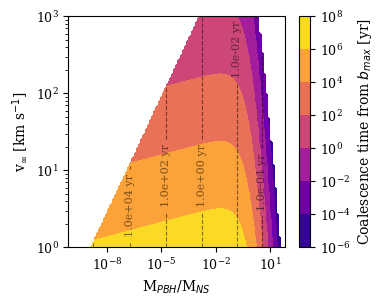

In [72]:
coal_bmax = np.zeros_like(M_grid)
coal_bmin = np.zeros_like(M_grid)
for j in range(gridsize):
    x_vals = []
    y_vals = []
    for i in range(gridsize):
        # print(m, M_star, R_star, v)
        v = v_inf_values[i]
        coal_min = coalescence_time(b_min_values[i,j], m_pbh_values[j], M_star, v) 
        coal_max = coalescence_time(b_max_values[i,j], m_pbh_values[j], M_star, v)
        coal_bmin[i, j] = coal_min
        coal_bmax[i, j] = coal_max
        print(f'Coalescence time for mPBH = {m_pbh_values[j]}, v = {v}:', coal_min, coal_max)

# Mask coalescence times with zzero capture cross-section
coal_bmin = np.where(cross_section_grid == 0, np.nan, coal_bmin)
coal_bmax = np.where(cross_section_grid == 0, np.nan, coal_bmax)
plt.figure(figsize=(3.5, 3))
v_inf_values_kms = [v.to(u.km/u.s).value for v in (v_inf_values * u.m/u.s)]
v_inf_values_auyr = [v.to(u.au/u.yr).value for v in (v_inf_values * u.m/u.s)]
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
m_pbh_values_in_Mstar = m_pbh_values / M_star   
plt.contourf(m_pbh_values_in_Mstar, v_inf_values_kms, coal_bmax,
             cmap='plasma', norm=plt.cm.colors.LogNorm())
# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')
cbar = plt.colorbar()
cbar.set_label(r'Coalescence time from $b_{max}$ [yr]')
# ✅ Contour also uses linear values
contour = plt.contour(m_pbh_values_in_Mstar, v_inf_values_kms, coal_bmin,
                      colors='black', linewidths=0.8, norm=plt.cm.colors.LogNorm(),
                      linestyles='--', alpha=0.5)
# Add labels to contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: fr"{x:.1e} yr")
plt.xlabel(r'M$_{PBH}$/M$_{NS}$')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_coalescence_time_grid.png',         
            bbox_inches='tight')

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

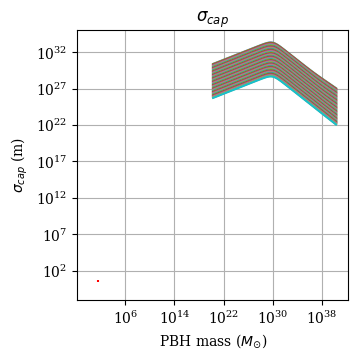

<Figure size 350x350 with 0 Axes>

In [ ]:

# Figure 2
plt.figure(figsize=(3.5,3.5))
for v in  v_inf_values:
    b_min= b_minimum(M_star, R_star, v)
    crossecc = []
    for m in m_pbh_values:
        # print(m, M_star, R_star, v)
        b_max = compute_b_max(m, M_star, v, b_min) 
        crossecc.append(compute_capture_crossec(b_min, b_max))   
    plt.loglog(m_pbh_values, crossecc )
plt.xlabel(r"PBH mass ($M_{\odot}$)")
plt.ylabel(r"$\sigma_{cap}$ (m)")
plt.title(r"$\sigma_{cap}$ ")
plt.grid(True, which="both")
plt.vlines(np.log10(M_bh), np.log10(v_inf_values[0]), np.log10(v_inf_values[-1]), color='red', linestyle='--')

plt.savefig(directoryp + f'{star}_capture_cross_section.png')
